In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

import pickle

import sys
import os
sys.path.append("/home/gc/workspace/drugPert/XPert")
os.chdir("/home/gc/workspace/drugPert/XPert")
os.getcwd()

%load_ext autoreload
%autoreload 2

# 获得相应的数据

In [2]:
adata = sc.read_h5ad('processed_data/l1000_sdst_78453_5.h5ad')
tissue_idx_dict = np.load('processed_data/l1000_tissue2idx_21.npy', allow_pickle=True).item()
idx2tissue = {v:k for k,v in tissue_idx_dict.items()}
adata.obs['tissue'] = adata.obs.tissue_idx.map(idx2tissue)
adata

AnnData object with n_obs × n_vars = 78453 × 978
    obs: 'sample_id', 'bead_batch', 'nearest_dose', 'pert_dose', 'pert_dose_unit', 'pert_idose', 'pert_time', 'pert_itime', 'pert_time_unit', 'cell_mfc_name', 'pert_mfc_id', 'det_plate', 'det_well', 'rna_plate', 'rna_well', 'count_mean', 'count_cv', 'qc_f_logp', 'qc_iqr', 'qc_slope', 'pert_id', 'pert_type', 'cell_iname', 'qc_pass', 'dyn_range', 'inv_level_10', 'build_name', 'failure_mode', 'project_code', 'cmap_name', 'n_replicates', 'pert_idx', 'cell_idx', 'tissue_idx', 'cell_pert_dose_time', 'split_1', 'split_2', 'split_3', 'split_4', 'split_5', 'split_cold_drug_1', 'split_cold_drug_2', 'split_cold_drug_3', 'split_cold_drug_4', 'split_cold_drug_5', 'split_cold_cell_1', 'split_cold_cell_2', 'split_cold_cell_3', 'split_cold_cell_4', 'split_cold_cell_5', 'split_cold_cell_1_one_shot', 'split_cold_cell_1_0.1_shot', 'split_cold_cell_1_0.3_shot', 'split_cold_cell_1_0.5_shot', 'split_cold_cell_1_0.8_shot', 'split_cold_cell_2_one_shot', 'split_

In [3]:
drug_info = pd.read_csv('processed_data/l1000_sdst_drugs_info_8432.csv', index_col=0)
select_moa = "HDAC inhibitor"
HDAC_drug_info = drug_info[drug_info.moa==select_moa]
HDAC_drug_id_ls = HDAC_drug_info.index.unique()
adata_filter = adata[adata.obs.pert_id.isin(HDAC_drug_id_ls)]
adata_filter.obs.tissue.value_counts()

tissue
unknown                               136
lung                                  100
breast                                 72
prostate                               53
haematopoietic_and_lymphoid_tissue     36
kidney                                 35
central_nervous_system                 32
skin                                   31
soft_tissue                            28
large_intestine                        26
liver                                  15
bone                                   15
ovary                                  13
pancreas                               13
endometrium                            11
cervix                                 11
autonomic_ganglia                       7
urinary_tract                           6
stomach                                 4
upper_aerodigestive_tract               2
placenta                                1
Name: count, dtype: int64

In [4]:
# tissue = 'lung'

# select_adata = adata[(adata.obs.tissue == tissue) & (adata.obs.pert_id.isin(HDAC_drug_id_ls))]

tissue = 'all'
select_adata = adata[(adata.obs.tissue != "unknown") & (adata.obs.pert_id.isin(HDAC_drug_id_ls))]

select_adata.obs.cmap_name.value_counts()

cmap_name
entinostat         71
panobinostat       58
vorinostat         45
valproic-acid      40
belinostat         26
mocetinostat       22
dacinostat         21
JNJ-26481585       20
ACY-1215           20
SB-939             20
MC1568             20
PCI-24781          17
apicidin           11
resminostat        10
PCI-34051          10
HNHA               10
HDAC3-selective    10
ISOX                9
droxinostat         9
tubastatin-a        9
NCH-51              9
scriptaid           8
Merck60             7
romidepsin          6
NSC-3852            6
WT-171              5
givinostat          5
sodium-butyrate     4
tubacin             3
Name: count, dtype: int64

In [5]:
select_adata = select_adata[select_adata.obs.cmap_name.isin(['vorinostat', 'belinostat','entinostat'])]
select_adata.n_obs

142

In [6]:
dataset_name = f"l1000_sdst_{tissue}_{select_moa.split(' ')[0]}"
select_adata.write_h5ad(f'processed_data_infer/{dataset_name}.h5ad')

/home/gc/.conda/envs/openbiomed/lib/python3.9/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


# 用指定的数据得到attn profile

In [ ]:
from datasets.MyDataset import MyDataset
from models.model_XPert import XPertNet
from metrics import get_metrics_infer

import torch
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
import yaml
import logging
import time
from argparse import Namespace

In [ ]:
file_name = f"HDACi_{tissue.split('_')[0]}"
expt_folder = f"experiment_snn_infer/plot_attn_molecule/{file_name}/" 
if not os.path.exists(expt_folder):
    os.makedirs(expt_folder)
timestamp = time.strftime('%Y%m%d_%H%M%S', time.localtime())

config_path = "configs/config_snn.yaml"
with open(f'{config_path}', 'r') as f:
    config = yaml.safe_load(f)
print(config)


args = Namespace(
    mode="infer",
    nfold="split_1",
    drug_feat="unimol",
    device="cuda:1",
    model="XPert_SNN",
    config="config",
    seed=0,
    dataset=dataset_name,
    pretrained_mode="global",
    include_cell_idx=False,
    wo_HG=False,
    wo_atom=False,
    wo_atom_HG=False,
    wo_unimol=False,
    wo_ppi=False,
    use_gene_pos_emed=False,
    drug_pos_emb_type="learnable",
    wo_cell_loss=False,
    wo_pcc_loss=False,
    use_gradscaler=False,
    lr_scheduler=True,
    resume_from=None,
    saved_model_path="experiment_snn/sdst_five_seeds",
    saved_model=None,
    pretrained_model=None,
    output_profile=False,
    output_attention=True,
    output_cls_embed=False,
    weighted_loss=False,
    kl_loss=False,
)

print(args)

{'model': {'XPert': None, 'ATTN': {'n_heads': 8, 'attention_probs_dropout_prob': 0.1, 'hidden_dropout_prob': 0.1, 'cell_input_hidden_dropout_prob': 0.1, 'drug_input_hidden_dropout_prob': 0.1, 'topk_cell': 128, 'topk_drug': 32, 'sparse_flag': False, 'hidden_size': 256, 'trt_structure': 'CA+SA+SA+CA', 'ctl_structure': 'SA+SA+SA+SA', 'ppi_gene_vector_path': 'processed_data/PPI_gene_vector_128d.npy'}, 'HG': {'node_input_dim': 512, 'conv_layers': 2, 'hg_path': 'processed_data_HG_L1000/', 'drug_hg_pretrained_embed_path': 'processed_data_HG_L1000/HG_drug_embeddings_20241109_120917.npy', 'specific_pretrained_embed_path': None}}, 'dataset': {'n_bins': 128, 'gene_num': 978, 'atom_num': 24, 'max_atom_size': 122, 'max_value': 15.002, 'min_value': 0.0, 'l1000': {'num_pert_dose': 10, 'num_pert_time': 3, 'num_cell_id': 240, 'num_tissue_id': 21}, 'panacea': {'num_pert_dose': 10, 'num_pert_time': 3, 'num_cell_id': 240, 'num_tissue_id': 21}, 'cdsdb': {'num_pert_dose': 11, 'num_pert_time': 8, 'num_cell_i

In [9]:
# define logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG) # .DEBUG/INFO/WARNING/ERROR/CRITICAL
fh = logging.FileHandler(expt_folder+f'/{file_name}_{timestamp}.log')
fh.setLevel(logging.DEBUG)
logger.addHandler(fh)
ch = logging.StreamHandler()
ch.setLevel(logging.DEBUG)
logger.addHandler(ch)

In [10]:
def load_infer_dataloader(args,config,logger):

    batch_size = 1
    data = sc.read_h5ad(f'processed_data_infer/{args.dataset}.h5ad')
    drug_feat = np.load(config['dataset']['drug_unimol_path'], allow_pickle=True)

    test_data = data

    print(f'Test data:{test_data.n_obs}')

    if 'l1000' not in args.dataset:
        max_value = round(data.X.max(),1)
        min_value = round(data.X.min(),1)
        print(f'For dataset {args.dataset}, max_value:{max_value}, min_value:{min_value}')
    else:
        max_value, min_value = None, None

    print("Starting load infer data...")
    test_dataset = MyDataset(test_data, drug_feat, args=args, config=config, logger=logger, max_value=max_value, min_value=min_value)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=10, drop_last=False)

    print(f'Test dataloader:{len(test_dataloader)}')
    
    return test_dataloader


In [ ]:
output_attention_branch = ["trt"]
output_attention_layers = ["CA_0", "CA_3"]
output_attention_mode = "mean_heads"  # .mean(axis=0).mean(axis=0)

def infer(model, dataloader, args, config, flag=True, output_profile=False, scaler=None):
    model.eval()  
    trt_raw_data_ls = []
    output2_ls = []
    ctl_raw_data_ls = []
    pert_id_ls = []
    cell_id_ls = []
    pert_dose_ls = []
    pert_time_ls = []
    trt_attention_dict_ls= {}
    ctl_attention_dict_ls= {}
    cls_embed_ls = []


    with torch.no_grad():  

        for data in dataloader:
            trt_raw_data, ctl_raw_data, trt_raw_data_binned, ctl_raw_data_binned, drug_feat, pert_dose_idx, pert_time_idx, drug_idx, cell_idx, tissue_idx, pert_id, cell_id, pert_dose, pert_time = data
            # feat_data = trt_raw_data, ctl_raw_data, trt_raw_data_binned, ctl_raw_data_binned,drug_feat, pert_dose_idx, pert_time_idx, drug_idx, cell_idx, tissue_idx  

            if scaler:
                with autocast():
                    trt_output, ctl_output, output_deg, _, _, attention_dict, _, _, cls_embed= model((trt_raw_data, ctl_raw_data, trt_raw_data_binned, ctl_raw_data_binned,drug_feat, pert_dose_idx, pert_time_idx, drug_idx, cell_idx, tissue_idx))
            else:
                trt_output, ctl_output, output_deg, _, _, attention_dict, _, _, cls_embed = model((trt_raw_data, ctl_raw_data, trt_raw_data_binned, ctl_raw_data_binned,drug_feat, pert_dose_idx, pert_time_idx, drug_idx, cell_idx, tissue_idx))                     

            if flag:
                trt_raw_data_ls.append(trt_raw_data)
                output2_ls.append(output_deg.cpu()+ctl_raw_data)
                ctl_raw_data_ls.append(ctl_raw_data)
                if args.output_attention:
                    trt_attention_dict, ctl_attention_dict = attention_dict
                    if "trt" in output_attention_branch:
                        for key, value in trt_attention_dict.items():
                            # print(key, value.shape)
                            if key in output_attention_layers:
                                if key not in trt_attention_dict_ls:
                                    trt_attention_dict_ls[key] = []
                                trt_attention_dict_ls[key].append(value.mean(axis=1).mean(axis=1) if output_attention_mode=="mean_heads" else value)
                    if "ctl" in output_attention_branch:
                        for key, value in ctl_attention_dict.items():
                            if key in output_attention_layers:
                                if key not in ctl_attention_dict_ls:
                                    ctl_attention_dict_ls[key] = []
                                ctl_attention_dict_ls[key].append(value.mean(axis=1).mean(axis=1) if output_attention_mode=="mean_heads" else value)

                if args.output_cls_embed:
                    cls_embed_ls.append(cls_embed)

                pert_id = list(drug_idx)
                cell_id = list(cell_id)
                pert_dose = list(pert_dose)
                pert_time = list(pert_time)

                pert_id_ls.extend(pert_id)
                cell_id_ls.extend(cell_id)
                pert_dose_ls.extend(pert_dose)
                pert_time_ls.extend(pert_time)


        if flag:
            y_true = torch.cat(trt_raw_data_ls, dim=0).cpu().detach().numpy()
            y_pred = torch.cat(output2_ls, dim=0).cpu().detach().numpy()
            ctl_true = torch.cat(ctl_raw_data_ls, dim=0).cpu().detach().numpy()
            metrics, metrics_all_ls = get_metrics_infer(y_true, y_pred, ctl_true)

            metrics_all_ls['pert_id'] = np.array(pert_id_ls)
            metrics_all_ls['cell_id'] = np.array(cell_id_ls)
            metrics_all_ls['pert_dose'] = np.array(pert_dose_ls)
            metrics_all_ls['pert_time'] = np.array(pert_time_ls)
        else:
            metrics = None
            metrics_all_ls = None

        
        
        # output attention
        all_attention_dict = None
        if args.output_attention:
            all_attention_dict = {}
            all_trt_attention_dict = {}
            all_ctl_attention_dict = {}
            if trt_attention_dict_ls != {}:
                for key, value in trt_attention_dict_ls.items():
                    all_trt_attention_dict[key] = torch.cat(value, dim=0).cpu().detach().numpy()
                all_attention_dict['trt'] = all_trt_attention_dict
            if ctl_attention_dict_ls != {}:
                for key, value in ctl_attention_dict_ls.items():
                    all_ctl_attention_dict[key] = torch.cat(value, dim=0).cpu().detach().numpy()
                all_attention_dict['ctl'] = all_ctl_attention_dict 

        # output cls_embed
        all_cls_embed = None
        if args.output_cls_embed:
            all_cls_embed = torch.cat(cls_embed_ls, dim=0).cpu().detach().numpy()

    
        if output_profile:
            output_pred_profile = {}
            output_pred_profile['y_true'] = y_true
            output_pred_profile['y_pred'] = y_pred
            output_pred_profile['ctl_true'] = ctl_true
            output_pred_profile['deg_true'] = y_true-ctl_true
            output_pred_profile['deg_pred'] = y_pred-ctl_true
        else:
            output_pred_profile = None

    return metrics, metrics_all_ls, output_pred_profile, all_attention_dict, all_cls_embed

In [ ]:
test_dataloader = load_infer_dataloader(args,config, logger)
device = args.device
fold = args.nfold
model = XPertNet(args, config, device, logger)
model.to(device)

all_attention_dict = {}
for seed in [0,1,2,3,4]:
    print(f'=================== seed {seed} ===================')
    saved_model = f"{args.saved_model_path}/xpert_seed{seed}/{fold}_fold_early_stop.pth"
    print(f'Loading model from {saved_model}')
    checkpoint = torch.load(saved_model)
    model_dict = model.state_dict()
    pretrained_dict = {k:v for k,v in checkpoint['model_state_dict'].items() if k in model_dict and v.shape == model_dict[k].shape}
    model_dict.update(pretrained_dict)
    model.load_state_dict(model_dict)


    start_time = time.time()
    logger.info('Start testing  ... ')
    logger.info('Testing on test dataset:')
    test_metrics, test_metrics_all_ls, test_output_pred_profile, test_all_attention_dict, all_cls_embed = infer(model, test_dataloader, args, config, flag=True, output_profile=args.output_profile, scaler=args.use_gradscaler)

    logger.info(f"{int(time.time() - start_time)/60:.2f}mins")
    logger.info('Test Metrics:')
    logger.info(test_metrics)

    all_attention_dict[f"seed{seed}"] = test_all_attention_dict

pert_dose_idx:
pert_dose_idx
8    142
Name: count, dtype: int64
binning process... n_bins:128


Test data:142
Starting load infer data...


100%|██████████| 142/142 [00:00<00:00, 1494.97it/s]
For cell embedding: using ppi_gene_vector + exp embedding


Test dataloader:142


Using sparse attn: False
Using sparse attn: False


...

Start testing  ... 
Testing on test dataset:
0.08mins
Test Metrics:
{'MSE': 0.472, 'RMSE': 0.687, 'MAE': 0.488, 'Pearson': 0.956, 'Spearman': 0.953, 'Precision@10 Positive': 0.994, 'Precision@10 Negative': 0.981, 'Precision@20 Positive': 0.991, 'Precision@20 Negative': 0.975, 'Precision@50 Positive': 0.963, 'Precision@50 Negative': 0.938, 'Precision@100 Positive': 0.823, 'Precision@100 Negative': 0.816, 'MSE_deg': 0.472, 'RMSE_deg': 0.687, 'MAE_deg': 0.488, 'Pearson_deg': 0.819, 'Spearman_deg': 0.801, 'Precision@10 Positive_deg': 0.93, 'Precision@10 Negative_deg': 0.946, 'Precision@20 Positive_deg': 0.89, 'Precision@20 Negative_deg': 0.907, 'Precision@50 Positive_deg': 0.777, 'Precision@50 Negative_deg': 0.807, 'Precision@100 Positive_deg': 0.616, 'Precision@100 Negative_deg': 0.645}


=================== seed 3 ===================
Loading model from experiment_snn/sdst_five_seeds/xpert_seed3/split_1_fold_early_stop.pth


Start testing  ... 
Testing on test dataset:
0.08mins
Test Metrics:
{'MSE': 0.473, 'RMSE': 0.687, 'MAE': 0.488, 'Pearson': 0.956, 'Spearman': 0.952, 'Precision@10 Positive': 0.996, 'Precision@10 Negative': 0.98, 'Precision@20 Positive': 0.99, 'Precision@20 Negative': 0.974, 'Precision@50 Positive': 0.961, 'Precision@50 Negative': 0.942, 'Precision@100 Positive': 0.824, 'Precision@100 Negative': 0.816, 'MSE_deg': 0.473, 'RMSE_deg': 0.687, 'MAE_deg': 0.488, 'Pearson_deg': 0.818, 'Spearman_deg': 0.799, 'Precision@10 Positive_deg': 0.931, 'Precision@10 Negative_deg': 0.946, 'Precision@20 Positive_deg': 0.883, 'Precision@20 Negative_deg': 0.918, 'Precision@50 Positive_deg': 0.772, 'Precision@50 Negative_deg': 0.813, 'Precision@100 Positive_deg': 0.612, 'Precision@100 Negative_deg': 0.649}


=================== seed 4 ===================
Loading model from experiment_snn/sdst_five_seeds/xpert_seed4/split_1_fold_early_stop.pth


Start testing  ... 
Testing on test dataset:
0.08mins
Test Metrics:
{'MSE': 0.469, 'RMSE': 0.685, 'MAE': 0.487, 'Pearson': 0.956, 'Spearman': 0.953, 'Precision@10 Positive': 0.995, 'Precision@10 Negative': 0.983, 'Precision@20 Positive': 0.988, 'Precision@20 Negative': 0.975, 'Precision@50 Positive': 0.961, 'Precision@50 Negative': 0.941, 'Precision@100 Positive': 0.823, 'Precision@100 Negative': 0.819, 'MSE_deg': 0.469, 'RMSE_deg': 0.685, 'MAE_deg': 0.487, 'Pearson_deg': 0.822, 'Spearman_deg': 0.802, 'Precision@10 Positive_deg': 0.918, 'Precision@10 Negative_deg': 0.956, 'Precision@20 Positive_deg': 0.886, 'Precision@20 Negative_deg': 0.92, 'Precision@50 Positive_deg': 0.768, 'Precision@50 Negative_deg': 0.823, 'Precision@100 Positive_deg': 0.617, 'Precision@100 Negative_deg': 0.652}


In [13]:
test_all_attention_dict.keys(), test_all_attention_dict["trt"].keys(), test_all_attention_dict["trt"]["CA_0"].shape

(dict_keys(['trt']), dict_keys(['CA_0', 'CA_3']), (142, 122))

# 定义分子可视化函数

In [ ]:
from experiment_snn_infer.plot_attn_molecule.molecule_vis import visualize_molecule_attention, plot_attention_heatmap, plot_attention_scatter
from rdkit import Chem

drug_smi = np.load('processed_data/all_drugs_idx2smi_8981.npy', allow_pickle=True).item()


def drawAttn(drug_name, all_attn_dict, seed, layer, start_idx=4, save_path=None, norm=True, figsize=(18,6), radius=30):
    # attn: an unique attention matrix, shape: [seq_len, seq_len]
    # start_idx: if sdst, start_idx=2; if mdmt, start_idx=4;

    idx_ls = np.where(select_adata.obs.cmap_name == drug_name)[0]
    idx = idx_ls[0]
    drug_idx = select_adata.obs.iloc[idx, :]['pert_idx']
    smi = drug_smi[drug_idx]

    mol = Chem.MolFromSmiles(smi)
    num_atom = mol.GetNumAtoms()
    
    atom_attn_dict = {}
    atom_attn_mean_dict = {}
    for key in all_attn_dict.keys():
        attn_dict = all_attn_dict[key]["trt"]
        if '+' not in layer:
            attn = np.array([attn_dict[layer][idx] for idx in idx_ls])
            atom_attn = attn[:, start_idx:start_idx+num_atom]
            atom_attn_mean = atom_attn.mean(axis=0)
        else:
            attn_1 = np.array([attn_dict["CA_0"][idx] for idx in idx_ls])
            atom_attn_1 = attn_1[:, start_idx:start_idx+num_atom]
            atom_attn_1_mean = atom_attn_1.mean(axis=0)

            attn_2 = np.array([attn_dict["CA_3"][idx] for idx in idx_ls])
            atom_attn_2 = attn_2[:, start_idx:start_idx+num_atom]
            atom_attn_2_mean = attn_2.mean(axis=0)

            atom_attn = (atom_attn_1 + atom_attn_2) / 2
            atom_attn_mean = (atom_attn_1_mean + atom_attn_2_mean) / 2
        
        atom_attn_dict[key] = atom_attn
        atom_attn_mean_dict[key] = atom_attn_mean
    
    # fig, axes = plt.subplots(3, 1, figsize=figsize, gridspec_kw={'height_ratios': [1.2, 1, 1]} )
    fig, axes = plt.subplots(1, 3, figsize=figsize, gridspec_kw={'width_ratios': [1, 1, 1]} )
    axes = axes.flatten()

    attention_mean_arr = np.array([atom_attn_mean_dict[f"seed{i}"] for i in range(5)])

    if seed == "mean":
        atom_attn_mean_seed = attention_mean_arr.mean(axis=0)
        atom_attn_heatmap_for_one_seed = atom_attn_dict[f"seed0"]
    else:
        atom_attn_mean_seed = atom_attn_mean_dict[f"seed{seed}"]
        atom_attn_heatmap_for_one_seed = atom_attn_dict[f"seed{seed}"]

    visualize_molecule_attention(smi, atom_attn_mean_seed, norm=norm, radius=radius, save_path=None, color_factor=0.5, ax=axes[0])

    plot_attention_heatmap(atom_attn_heatmap_for_one_seed, annot=False, save_path=None, ax=axes[1])

    # plot scatter across seeds
    plot_attention_scatter(attention_mean_arr, cmap='Paired', ax=axes[2])

    fig.suptitle(f'Attention Visualization for {drug_name.capitalize() if not drug_name[0].isupper() else drug_name}', fontsize=24, y=1.1)
    # plt.tight_layout()
    plt.subplots_adjust(wspace=0.2)

    if save_path:
        fig.savefig(save_path, format="svg", dpi=300, bbox_inches='tight')
        print(f"Saving to: {save_path}")
    
    # Output atom_attn_dict as DataFrame
    attn_dfs = []
    for key in atom_attn_dict.keys():
        attn_df = pd.DataFrame(atom_attn_dict[key].T) # [num_atom, num_sample]
        attn_df.columns = [f"{key}"] * attn_df.shape[1]
        attn_dfs.append(attn_df)
    attn_df = pd.concat(attn_dfs, axis=1)

    # Output atom_attn_mean_dict as DataFrame
    for key in atom_attn_mean_dict.keys():
        attn_df[f"{key}_mean"] = atom_attn_mean_dict[key]
        
    # Output atom types and mean attention scores
    atom_ls = [atom.GetSymbol() for atom in mol.GetAtoms()]
    print(atom_ls)
    attn_df.index = atom_ls
    attn_df["five_seeds_mean_attenion"] = atom_attn_mean_seed

    plt.show()

    return fig, attn_df

# 分子可视化

In [15]:
select_adata.obs.cmap_name.value_counts()

cmap_name
entinostat    71
vorinostat    45
belinostat    26
Name: count, dtype: int64

['O', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'O', 'N', 'C', 'C', 'C', 'C', 'C', 'C', 'N', 'O']


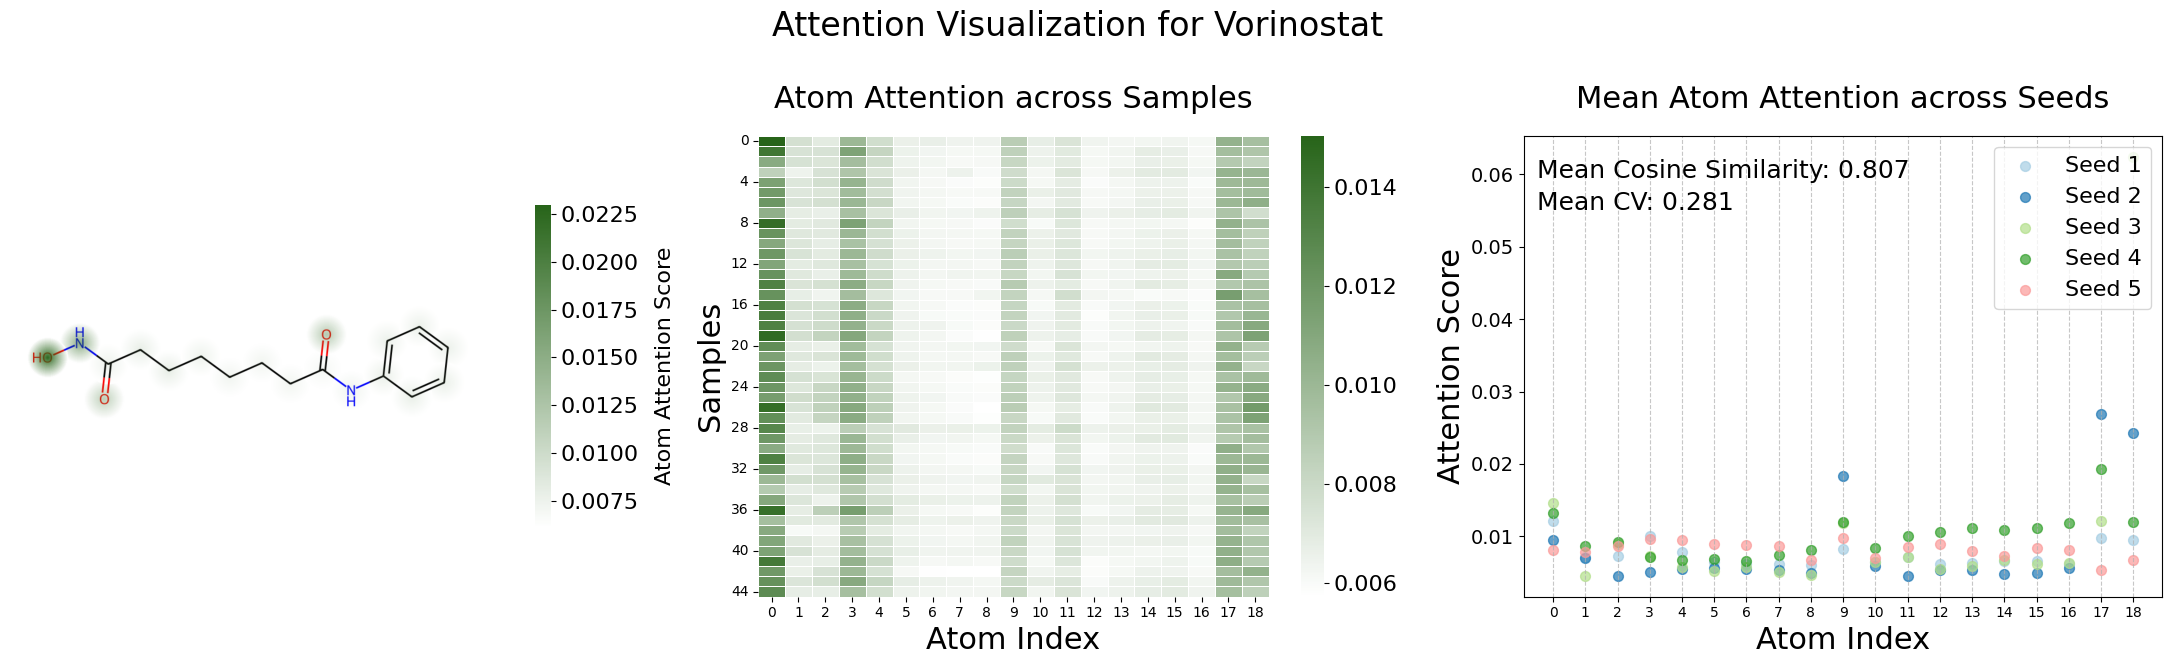

['O', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'S', 'O', 'O', 'N', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'N', 'O']


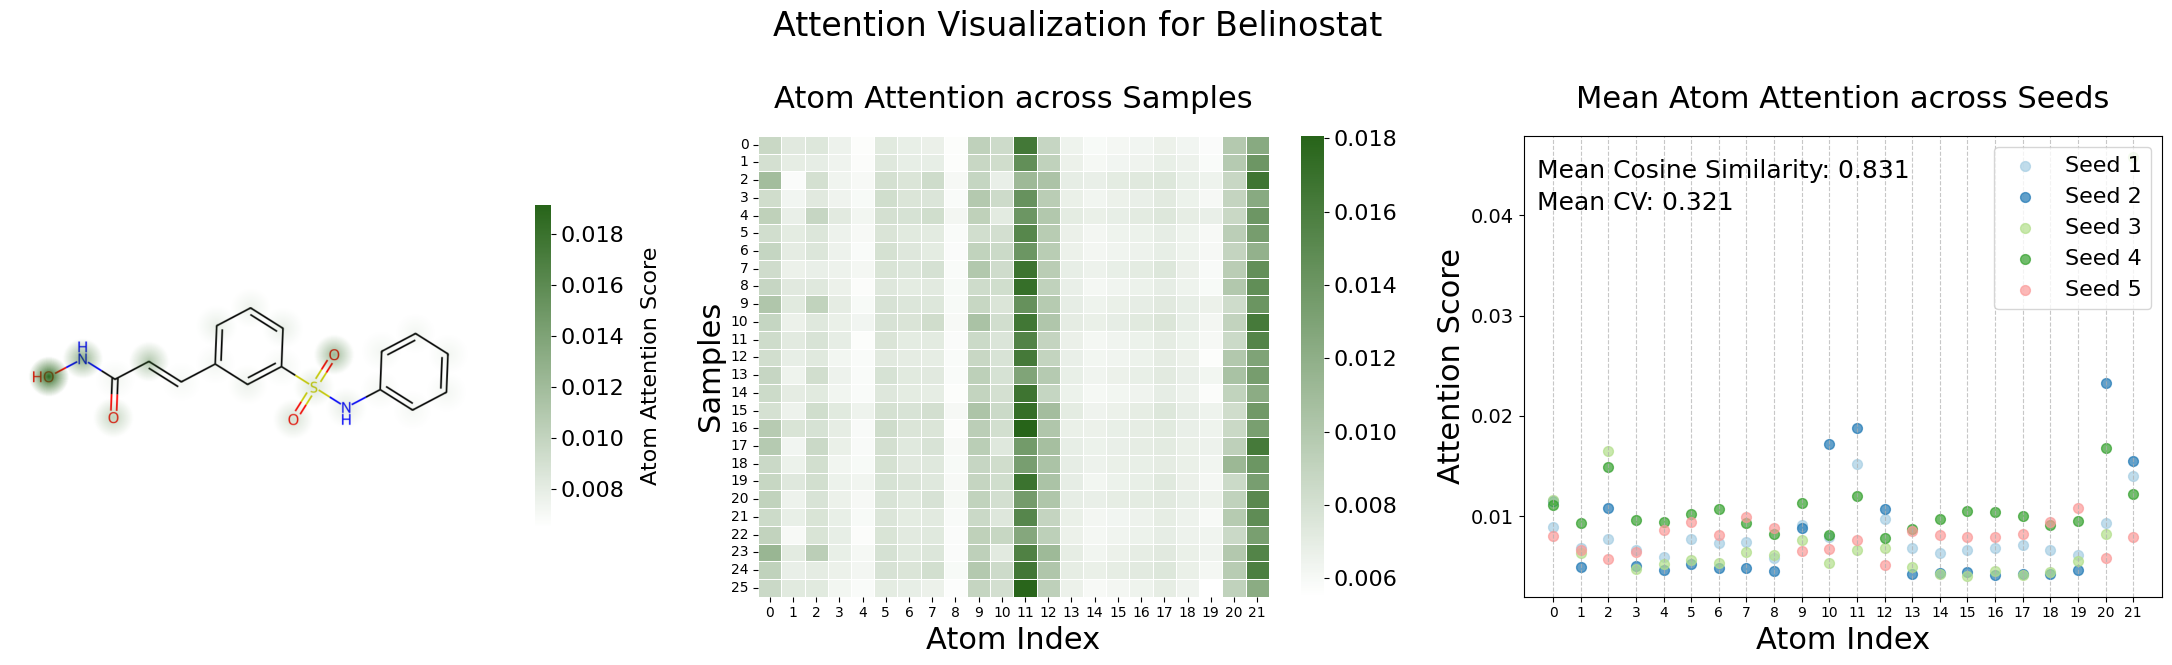

In [16]:
layer = 'CA_0+CA_3'
seed = 0
attention_dict_trt = all_attention_dict

drug_list = select_adata.obs.cmap_name.unique().tolist()
drug_list = ["vorinostat", "belinostat"]

# for seed in [0,1,2,3,4]:
for seed in ["mean"]:    
    for drug_name in drug_list:
        # save_path = f'{expt_folder}{tissue}_{drug_name}_seed_{seed}_layer_{layer}_mean.svg'
        save_path = None
        fig, attn_df = drawAttn(drug_name, attention_dict_trt, seed, layer, start_idx=2, figsize=(22,6), save_path=save_path, radius=35)
        attn_df.to_csv(f'{expt_folder}{tissue}_{drug_name}_seed_{seed}_layer_{layer}_mean_atom_attention.csv')
        

In [17]:
attn_df

,seed0,seed0,seed0,seed0,seed0,seed0,seed0,seed0,seed0,seed0,...,seed4,seed4,seed4,seed4,seed0_mean,seed1_mean,seed2_mean,seed3_mean,seed4_mean,five_seeds_mean_attenion
O,0.008653,0.008051,0.010890,0.008263,0.009238,0.008176,0.008881,0.008326,0.008836,0.010105,...,0.007705,0.007208,0.008221,0.007711,0.008952,0.011539,0.011670,0.011167,0.008028,0.010271
C,0.007294,0.007021,0.005832,0.006329,0.006792,0.007074,0.007025,0.006649,0.007296,0.007252,...,0.006286,0.006705,0.006063,0.006513,0.006849,0.004970,0.006341,0.009338,0.006674,0.006835
C,0.007481,0.006927,0.008030,0.007271,0.008814,0.007538,0.007517,0.006797,0.007390,0.009087,...,0.005042,0.005639,0.005290,0.005283,0.007797,0.010868,0.016492,0.014882,0.005734,0.011155
C,0.006553,0.006440,0.006405,0.006480,0.007183,0.006570,0.006564,0.006560,0.006646,0.007033,...,0.006223,0.006400,0.006222,0.005771,0.006675,0.005023,0.004758,0.009611,0.006465,0.006506
C,0.005701,0.005763,0.006016,0.005987,0.006273,0.006040,0.005887,0.006159,0.005783,0.005962,...,0.007514,0.008716,0.007645,0.008307,0.005989,0.004659,0.005231,0.009410,0.008691,0.006796
C,0.007235,0.007380,0.008031,0.008247,0.008049,0.007682,0.007986,0.007721,0.007445,0.007820,...,0.010366,0.008994,0.008874,0.008178,0.007766,0.005272,0.005641,0.010269,0.009476,0.007685
C,0.006842,0.006914,0.007645,0.007649,0.007885,0.007238,0.007451,0.007536,0.007084,0.007524,...,0.008007,0.008210,0.007463,0.007189,0.007346,0.004846,0.005373,0.010710,0.008121,0.007279
C,0.006712,0.006889,0.008379,0.007601,0.008214,0.007159,0.007085,0.007922,0.007179,0.007487,...,0.009887,0.010504,0.009936,0.009405,0.007473,0.004898,0.006416,0.009307,0.009956,0.007610
C,0.005718,0.005743,0.006064,0.005869,0.006231,0.005855,0.005822,0.005849,0.005950,0.005952,...,0.009057,0.009046,0.008925,0.008497,0.005903,0.004517,0.006203,0.008267,0.008832,0.006744
S,0.009196,0.008720,0.008884,0.009915,0.009259,0.008169,0.009089,0.009988,0.008391,0.008770,...,0.006814,0.005808,0.006053,0.006436,0.009170,0.008865,0.007624,0.011318,0.006536,0.008703
